In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
#df = pd.read_csv('polandia_hourly.csv')
df = pd.read_csv('fromCale/netherland_hourly.csv')
df


,utc_timestamp,cet_cest_timestamp,NL_load_actual_entsoe_transparency,NL_load_forecast_entsoe_transparency
0,2014-12-31T23:00:00Z,2015-01-01T00:00:00+0100,NaN,NaN
1,2015-01-01T00:00:00Z,2015-01-01T01:00:00+0100,9401.0,8937.0
2,2015-01-01T01:00:00Z,2015-01-01T02:00:00+0100,8957.0,8608.0
3,2015-01-01T02:00:00Z,2015-01-01T03:00:00+0100,8462.0,8462.0
4,2015-01-01T03:00:00Z,2015-01-01T04:00:00+0100,8156.0,8500.0
...,...,...,...,...
43819,2019-12-31T18:00:00Z,2019-12-31T19:00:00+0100,13517.0,12380.0
43820,2019-12-31T19:00:00Z,2019-12-31T20:00:00+0100,12799.0,11820.0
43821,2019-12-31T20:00:00Z,2019-12-31T21:00:00+0100,12065.0,11163.0
43822,2019-12-31T21:00:00Z,2019-12-31T22:00:00+0100,11641.0,10605.0


In [2]:
# Select data for training # 
fra = '2018-01-01'
til = '2018-12-01'
# Using between method (inclusive of both endpoints)
#data_2018 = df.loc[df['utc_timestamp'].between('2015-01-01', '2015-03-01')]
df = df.loc[(df['utc_timestamp'] >= fra) & (df['utc_timestamp'] <= til)]
df = df.rename(columns={'utc_timestamp': 'ds', 'NL_load_actual_entsoe_transparency': 'consumption'})

df

,ds,cet_cest_timestamp,consumption,NL_load_forecast_entsoe_transparency
26305,2018-01-01T00:00:00Z,2018-01-01T01:00:00+0100,10690.0,11048.0
26306,2018-01-01T01:00:00Z,2018-01-01T02:00:00+0100,10354.0,10711.0
26307,2018-01-01T02:00:00Z,2018-01-01T03:00:00+0100,10032.0,10577.0
26308,2018-01-01T03:00:00Z,2018-01-01T04:00:00+0100,9766.0,10654.0
26309,2018-01-01T04:00:00Z,2018-01-01T05:00:00+0100,9768.0,11085.0
...,...,...,...,...
34316,2018-11-30T19:00:00Z,2018-11-30T20:00:00+0100,15119.0,15692.0
34317,2018-11-30T20:00:00Z,2018-11-30T21:00:00+0100,14163.0,14656.0
34318,2018-11-30T21:00:00Z,2018-11-30T22:00:00+0100,13154.0,13595.0
34319,2018-11-30T22:00:00Z,2018-11-30T23:00:00+0100,12444.0,12779.0


In [3]:
# Convert the time column to datetime and set as index
# Replace 'timestamp_column' with the actual name in your CSV
df['timestamp'] = pd.to_datetime(df['ds'])
df = df.set_index('timestamp').sort_index()

# Quick check for missing hours
print(f"Dataset range: {df.index.min()} to {df.index.max()}")
df.head()

Dataset range: 2018-01-01 00:00:00+00:00 to 2018-11-30 23:00:00+00:00


,ds,cet_cest_timestamp,consumption,NL_load_forecast_entsoe_transparency
timestamp,,,,
2018-01-01 00:00:00+00:00,2018-01-01T00:00:00Z,2018-01-01T01:00:00+0100,10690.0,11048.0
2018-01-01 01:00:00+00:00,2018-01-01T01:00:00Z,2018-01-01T02:00:00+0100,10354.0,10711.0
2018-01-01 02:00:00+00:00,2018-01-01T02:00:00Z,2018-01-01T03:00:00+0100,10032.0,10577.0
2018-01-01 03:00:00+00:00,2018-01-01T03:00:00Z,2018-01-01T04:00:00+0100,9766.0,10654.0
2018-01-01 04:00:00+00:00,2018-01-01T04:00:00Z,2018-01-01T05:00:00+0100,9768.0,11085.0


In [4]:
def create_features(df):
    df = df.copy()
    
    # 1. Time Extracts
    df['hour'] = df.index.hour
    df['dayofweek'] = df.index.dayofweek
    df['month'] = df.index.month
    df['quarter'] = df.index.quarter
    df['is_weekend'] = df['dayofweek'].isin([5, 6]).astype(int)
    
    # 2. Lags (Looking back)
    # Target must be your consumption column name
    df['lag_24h'] = df['consumption'].shift(24) 
    df['lag_7d'] = df['consumption'].shift(24 * 7)
    
    # 3. Rolling Window (Average of the last 24 hours)
    df['roll_mean_24h'] = df['consumption'].shift(1).rolling(window=24).mean()
    
    return df.dropna()

df_ready = create_features(df)

In [5]:
df_ready

,ds,cet_cest_timestamp,consumption,NL_load_forecast_entsoe_transparency,hour,dayofweek,month,quarter,is_weekend,lag_24h,lag_7d,roll_mean_24h
timestamp,,,,,,,,,,,,
2018-01-08 00:00:00+00:00,2018-01-08T00:00:00Z,2018-01-08T01:00:00+0100,10872.0,10227.0,0,0,1,1,0,10896.0,10690.0,12527.208333
2018-01-08 01:00:00+00:00,2018-01-08T01:00:00Z,2018-01-08T02:00:00+0100,10684.0,9770.0,1,0,1,1,0,10462.0,10354.0,12526.208333
2018-01-08 02:00:00+00:00,2018-01-08T02:00:00Z,2018-01-08T03:00:00+0100,10664.0,9496.0,2,0,1,1,0,10282.0,10032.0,12535.458333
2018-01-08 03:00:00+00:00,2018-01-08T03:00:00Z,2018-01-08T04:00:00+0100,10844.0,9349.0,3,0,1,1,0,10244.0,9766.0,12551.375000
2018-01-08 04:00:00+00:00,2018-01-08T04:00:00Z,2018-01-08T05:00:00+0100,11419.0,9625.0,4,0,1,1,0,10363.0,9768.0,12576.375000
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-11-30 19:00:00+00:00,2018-11-30T19:00:00Z,2018-11-30T20:00:00+0100,15119.0,15692.0,19,4,11,4,0,15589.0,15250.0,14538.500000
2018-11-30 20:00:00+00:00,2018-11-30T20:00:00Z,2018-11-30T21:00:00+0100,14163.0,14656.0,20,4,11,4,0,14538.0,14258.0,14518.916667
2018-11-30 21:00:00+00:00,2018-11-30T21:00:00Z,2018-11-30T22:00:00+0100,13154.0,13595.0,21,4,11,4,0,13430.0,13296.0,14503.291667


In [6]:
# Define features and target
FEATURES = ['hour', 'dayofweek', 'month', 'quarter', 'is_weekend', 'lag_24h', 'lag_7d', 'roll_mean_24h']
TARGET = 'consumption'

# Split data
train = df_ready.loc[df_ready.index < '2018-11-01']
test = df_ready.loc[df_ready.index >= '2018-11-01']

X_train, y_train = train[FEATURES], train[TARGET]
X_test, y_test = test[FEATURES], test[TARGET]

In [7]:
test

,ds,cet_cest_timestamp,consumption,NL_load_forecast_entsoe_transparency,hour,dayofweek,month,quarter,is_weekend,lag_24h,lag_7d,roll_mean_24h
timestamp,,,,,,,,,,,,
2018-11-01 00:00:00+00:00,2018-11-01T00:00:00Z,2018-11-01T01:00:00+0100,10722.0,11382.0,0,3,11,4,0,10767.0,10551.0,14048.958333
2018-11-01 01:00:00+00:00,2018-11-01T01:00:00Z,2018-11-01T02:00:00+0100,10563.0,11072.0,1,3,11,4,0,10582.0,10536.0,14047.083333
2018-11-01 02:00:00+00:00,2018-11-01T02:00:00Z,2018-11-01T03:00:00+0100,10540.0,10977.0,2,3,11,4,0,10580.0,10606.0,14046.291667
2018-11-01 03:00:00+00:00,2018-11-01T03:00:00Z,2018-11-01T04:00:00+0100,10584.0,11034.0,3,3,11,4,0,10664.0,11046.0,14044.625000
2018-11-01 04:00:00+00:00,2018-11-01T04:00:00Z,2018-11-01T05:00:00+0100,11084.0,11475.0,4,3,11,4,0,11202.0,12402.0,14041.291667
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-11-30 19:00:00+00:00,2018-11-30T19:00:00Z,2018-11-30T20:00:00+0100,15119.0,15692.0,19,4,11,4,0,15589.0,15250.0,14538.500000
2018-11-30 20:00:00+00:00,2018-11-30T20:00:00Z,2018-11-30T21:00:00+0100,14163.0,14656.0,20,4,11,4,0,14538.0,14258.0,14518.916667
2018-11-30 21:00:00+00:00,2018-11-30T21:00:00Z,2018-11-30T22:00:00+0100,13154.0,13595.0,21,4,11,4,0,13430.0,13296.0,14503.291667


In [8]:
import lightgbm as lgb

model = lgb.LGBMRegressor(
    n_estimators=1000,
    learning_rate=0.01, # Slow and steady
    num_leaves=31,
    importance_type='gain'
)

model.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(stopping_rounds=50)]
)

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000120 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 814
[LightGBM] [Info] Number of data points in the train set: 7128, number of used features: 8
[LightGBM] [Info] Start training from score 12899.396886
Training until validation scores don't improve for 50 rounds
Did not meet early stopping. Best iteration is:
[999]	valid_0's l2: 193293


,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.01
,n_estimators,1000
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0
,min_child_weight,0.001
,min_child_samples,20


In [9]:
test

,ds,cet_cest_timestamp,consumption,NL_load_forecast_entsoe_transparency,hour,dayofweek,month,quarter,is_weekend,lag_24h,lag_7d,roll_mean_24h
timestamp,,,,,,,,,,,,
2018-11-01 00:00:00+00:00,2018-11-01T00:00:00Z,2018-11-01T01:00:00+0100,10722.0,11382.0,0,3,11,4,0,10767.0,10551.0,14048.958333
2018-11-01 01:00:00+00:00,2018-11-01T01:00:00Z,2018-11-01T02:00:00+0100,10563.0,11072.0,1,3,11,4,0,10582.0,10536.0,14047.083333
2018-11-01 02:00:00+00:00,2018-11-01T02:00:00Z,2018-11-01T03:00:00+0100,10540.0,10977.0,2,3,11,4,0,10580.0,10606.0,14046.291667
2018-11-01 03:00:00+00:00,2018-11-01T03:00:00Z,2018-11-01T04:00:00+0100,10584.0,11034.0,3,3,11,4,0,10664.0,11046.0,14044.625000
2018-11-01 04:00:00+00:00,2018-11-01T04:00:00Z,2018-11-01T05:00:00+0100,11084.0,11475.0,4,3,11,4,0,11202.0,12402.0,14041.291667
...,...,...,...,...,...,...,...,...,...,...,...,...
2018-11-30 19:00:00+00:00,2018-11-30T19:00:00Z,2018-11-30T20:00:00+0100,15119.0,15692.0,19,4,11,4,0,15589.0,15250.0,14538.500000
2018-11-30 20:00:00+00:00,2018-11-30T20:00:00Z,2018-11-30T21:00:00+0100,14163.0,14656.0,20,4,11,4,0,14538.0,14258.0,14518.916667
2018-11-30 21:00:00+00:00,2018-11-30T21:00:00Z,2018-11-30T22:00:00+0100,13154.0,13595.0,21,4,11,4,0,13430.0,13296.0,14503.291667


In [10]:
test['prediction'] = model.predict(X_test)
test

/var/folders/c1/2tphrm7s7m53qr3gb7x952f80000gn/T/ipykernel_45039/1149316294.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  test['prediction'] = model.predict(X_test)


,ds,cet_cest_timestamp,consumption,NL_load_forecast_entsoe_transparency,hour,dayofweek,month,quarter,is_weekend,lag_24h,lag_7d,roll_mean_24h,prediction
timestamp,,,,,,,,,,,,,
2018-11-01 00:00:00+00:00,2018-11-01T00:00:00Z,2018-11-01T01:00:00+0100,10722.0,11382.0,0,3,11,4,0,10767.0,10551.0,14048.958333,10708.447295
2018-11-01 01:00:00+00:00,2018-11-01T01:00:00Z,2018-11-01T02:00:00+0100,10563.0,11072.0,1,3,11,4,0,10582.0,10536.0,14047.083333,10636.437653
2018-11-01 02:00:00+00:00,2018-11-01T02:00:00Z,2018-11-01T03:00:00+0100,10540.0,10977.0,2,3,11,4,0,10580.0,10606.0,14046.291667,10636.437653
2018-11-01 03:00:00+00:00,2018-11-01T03:00:00Z,2018-11-01T04:00:00+0100,10584.0,11034.0,3,3,11,4,0,10664.0,11046.0,14044.625000,10827.844315
2018-11-01 04:00:00+00:00,2018-11-01T04:00:00Z,2018-11-01T05:00:00+0100,11084.0,11475.0,4,3,11,4,0,11202.0,12402.0,14041.291667,11635.981099
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-11-30 19:00:00+00:00,2018-11-30T19:00:00Z,2018-11-30T20:00:00+0100,15119.0,15692.0,19,4,11,4,0,15589.0,15250.0,14538.500000,15615.535715
2018-11-30 20:00:00+00:00,2018-11-30T20:00:00Z,2018-11-30T21:00:00+0100,14163.0,14656.0,20,4,11,4,0,14538.0,14258.0,14518.916667,14280.881912
2018-11-30 21:00:00+00:00,2018-11-30T21:00:00Z,2018-11-30T22:00:00+0100,13154.0,13595.0,21,4,11,4,0,13430.0,13296.0,14503.291667,13311.790660


In [11]:
result = test.copy()

In [12]:
import numpy as np
# 1. Calculate the Mean of Actual Values (Denominator)
y_mean = np.mean(result['consumption'])

# 2. Calculate rMAE (Relative Mean Absolute Error)
mae = np.mean(np.abs(result['consumption'] - result['prediction']))
rmae = mae / y_mean

# 3. Calculate rRMSE (Relative Root Mean Square Error)
rmse = np.sqrt(np.mean((result['consumption'] - result['prediction'])**2))
rrmse = rmse / y_mean

metricResult = f'rRMSE: {rrmse:.4f} rMAE: {rmae:.4f} '
print(metricResult)

rRMSE: 0.0316 rMAE: 0.0227 


In [13]:
city = 'Hourly The Netherland lgbm'
fra = '2018-11-01'

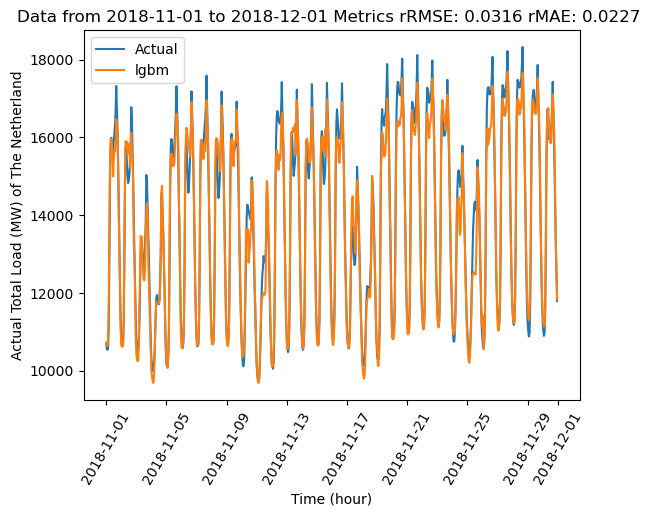

In [14]:
# plot Result dan save

plt.plot(result.index, result['consumption'], label='Actual')
plt.plot(result.index, result['prediction'],label='lgbm')
#plt.plot(fcst_df['ds'], fcst_df['TimeGPT-hi-80'])

# Menambahkan label sumbu dan judul plot
plt.xlabel('Time (hour)')
plt.xticks(rotation=60)  # Rotate labels by 45 degrees
plt.ylabel('Actual Total Load (MW) of The Netherland')
#plt.title('Plot of Combined Value over Date')
plt.title(f'Data from {fra} to {til} Metrics {metricResult}')


# Menambahkan legenda
plt.legend()

# Mengganti spasi dan karakter khusus dengan garis bawah
#result_cleaned = result.replace(' ', '_').replace(':', '_')

# Menyimpan plot ke file gambar dengan judul yang diperbarui
#plt.savefig(f'./time_gpt/result_pure_time_gpt_{result_cleaned}.png')
plt.savefig(f'Plot {city} from {fra} to {til} metric {metricResult}.png', dpi=300, bbox_inches='tight')

# Menampilkan plot
plt.show()


In [15]:
result

,ds,cet_cest_timestamp,consumption,NL_load_forecast_entsoe_transparency,hour,dayofweek,month,quarter,is_weekend,lag_24h,lag_7d,roll_mean_24h,prediction
timestamp,,,,,,,,,,,,,
2018-11-01 00:00:00+00:00,2018-11-01T00:00:00Z,2018-11-01T01:00:00+0100,10722.0,11382.0,0,3,11,4,0,10767.0,10551.0,14048.958333,10708.130756
2018-11-01 01:00:00+00:00,2018-11-01T01:00:00Z,2018-11-01T02:00:00+0100,10563.0,11072.0,1,3,11,4,0,10582.0,10536.0,14047.083333,10636.452210
2018-11-01 02:00:00+00:00,2018-11-01T02:00:00Z,2018-11-01T03:00:00+0100,10540.0,10977.0,2,3,11,4,0,10580.0,10606.0,14046.291667,10636.452210
2018-11-01 03:00:00+00:00,2018-11-01T03:00:00Z,2018-11-01T04:00:00+0100,10584.0,11034.0,3,3,11,4,0,10664.0,11046.0,14044.625000,10827.858872
2018-11-01 04:00:00+00:00,2018-11-01T04:00:00Z,2018-11-01T05:00:00+0100,11084.0,11475.0,4,3,11,4,0,11202.0,12402.0,14041.291667,11635.995656
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2018-12-31 19:00:00+00:00,2018-12-31T19:00:00Z,2018-12-31T20:00:00+0100,12802.0,16181.0,19,0,12,4,0,13666.0,13691.0,13027.666667,14361.757622
2018-12-31 20:00:00+00:00,2018-12-31T20:00:00Z,2018-12-31T21:00:00+0100,11962.0,15320.0,20,0,12,4,0,13002.0,13017.0,12991.666667,13600.113035
2018-12-31 21:00:00+00:00,2018-12-31T21:00:00Z,2018-12-31T22:00:00+0100,11482.0,14171.0,21,0,12,4,0,12359.0,12414.0,12948.333333,13668.044497


In [16]:

import pandas as pd
df_eval = pd.DataFrame({
    'actual': result['consumption'],
    'pred': result['prediction']
})

df_eval['error'] = df_eval['actual'] - df_eval['pred']
df_eval['abs_error'] = df_eval['error'].abs()

df_eval.head()

,actual,pred,error,abs_error
timestamp,,,,
2018-11-01 00:00:00+00:00,10722.0,10708.130756,13.869244,13.869244
2018-11-01 01:00:00+00:00,10563.0,10636.452210,-73.452210,73.452210
2018-11-01 02:00:00+00:00,10540.0,10636.452210,-96.452210,96.452210
2018-11-01 03:00:00+00:00,10584.0,10827.858872,-243.858872,243.858872
2018-11-01 04:00:00+00:00,11084.0,11635.995656,-551.995656,551.995656


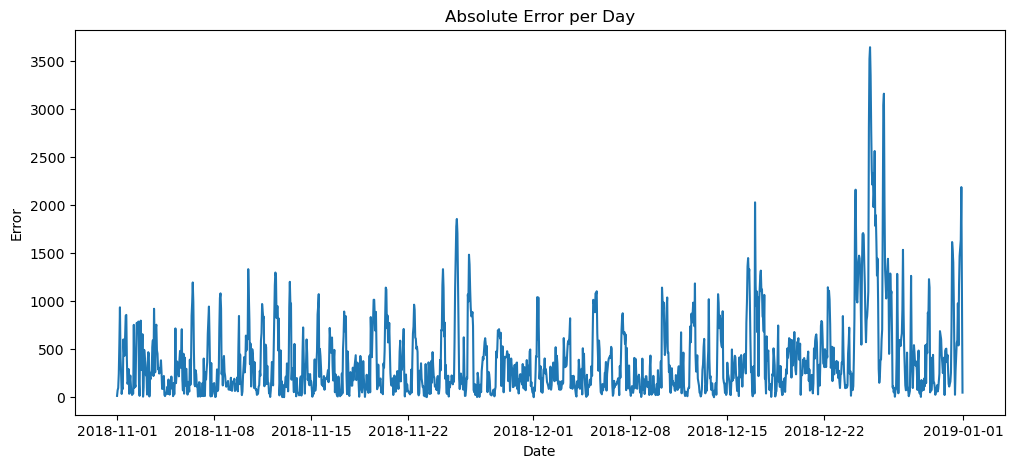

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(df_eval.index, df_eval['abs_error'])
plt.title("Absolute Error per Day")
plt.ylabel("Error")
plt.xlabel("Date")
plt.show()

In [18]:
df_eval['dayofweek'] = df_eval.index.dayofweek

error_by_day = df_eval.groupby('dayofweek')['abs_error'].mean()

print(error_by_day)

dayofweek
0    587.755535
1    459.856051
2    428.759705
3    314.960503
4    289.403280
5    335.540011
6    297.170284
Name: abs_error, dtype: float64


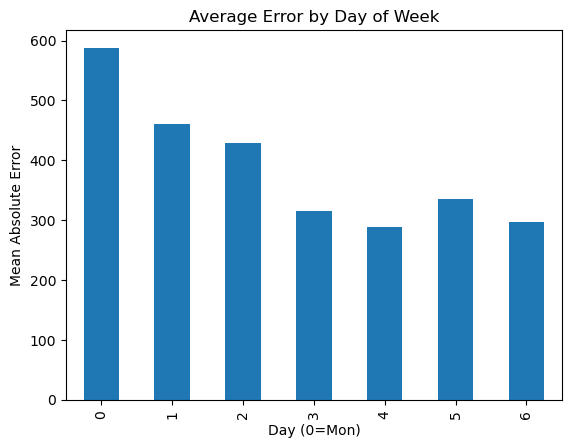

In [19]:
error_by_day.plot(kind='bar')
plt.title("Average Error by Day of Week")
plt.xlabel("Day (0=Mon)")
plt.ylabel("Mean Absolute Error")
plt.show()

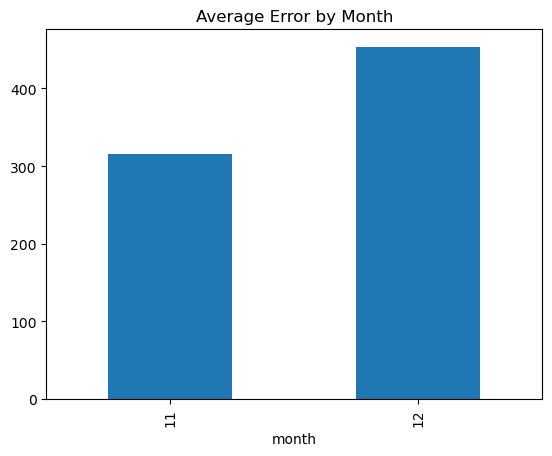

In [20]:
df_eval['month'] = df_eval.index.month

error_by_month = df_eval.groupby('month')['abs_error'].mean()

error_by_month.plot(kind='bar')
plt.title("Average Error by Month")
plt.show()

In [21]:
df_eval.sort_values('abs_error', ascending=False).head(10)

,actual,pred,error,abs_error,dayofweek,month
timestamp,,,,,,
2018-12-25 07:00:00+00:00,11990.0,15631.135092,-3641.135092,3641.135092,1,12
2018-12-25 06:00:00+00:00,11172.0,14690.801265,-3518.801265,3518.801265,1,12
2018-12-25 08:00:00+00:00,12652.0,15998.680752,-3346.680752,3346.680752,1,12
2018-12-26 07:00:00+00:00,12139.0,15296.530119,-3157.530119,3157.530119,2,12
2018-12-26 06:00:00+00:00,11339.0,14376.825291,-3037.825291,3037.825291,2,12
2018-12-25 05:00:00+00:00,10590.0,13396.181162,-2806.181162,2806.181162,1,12
2018-12-25 09:00:00+00:00,12884.0,15666.607877,-2782.607877,2782.607877,1,12
2018-12-25 15:00:00+00:00,13272.0,15833.461418,-2561.461418,2561.461418,1,12
2018-12-25 10:00:00+00:00,12846.0,15208.898303,-2362.898303,2362.898303,1,12
